In [8]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import pickle
from tqdm import tqdm

In [10]:
DEBIAS_LAYER = 15
TOTAL_LAYERS = 24
ACT_DM_DIR = "data/activations/dm"
ACT_LR_DIR = "data/activations/lr"
CAVS_DIR = "models/cavs"

target_layers = list(range(DEBIAS_LAYER, TOTAL_LAYERS))
original_lr_probe = pickle.load(open(os.path.join(CAVS_DIR, f"lr_model_layer_{DEBIAS_LAYER}.pkl"), "rb"))

In [11]:
def get_metrics_for_directory(acts_dir, original_probe):
    metrics = {'linear': [], 'tree': [], 'xgboost': []}
    
    print(f"\nEvaluating {acts_dir}...")
    for layer in tqdm(target_layers):
        csv_path = os.path.join(acts_dir, f"layer_{layer}.csv")
        df_acts = pd.read_csv(csv_path)
        labels = df_acts['label'].values
        x_layer = df_acts.drop(columns=['label']).values
        
        if original_probe is not None and layer == DEBIAS_LAYER:
            preds = original_probe.predict(x_layer)
            acc = accuracy_score(labels, preds)
            print(f"\n[INFO] Original Probe Accuracy exactly at DEBIAS_LAYER ({layer}): {acc:.4f}")
            
        x_train, x_test, y_train, y_test = train_test_split(x_layer, labels, test_size=0.2, random_state=42, stratify=labels)
        
        # new classifiers to capture recovery
        m_lin = LogisticRegression(max_iter=1000)
        m_tree = DecisionTreeClassifier(max_depth=4, min_samples_leaf=5)
        m_xgb = XGBClassifier(max_depth=4, n_estimators=50, reg_alpha=1.0)
        
        m_lin.fit(x_train, y_train)
        metrics['linear'].append(accuracy_score(y_test, m_lin.predict(x_test)))
        
        m_tree.fit(x_train, y_train)
        metrics['tree'].append(accuracy_score(y_test, m_tree.predict(x_test)))
        
        m_xgb.fit(x_train, y_train)
        metrics['xgboost'].append(accuracy_score(y_test, m_xgb.predict(x_test)))
        
    return metrics


In [12]:
metrics_dm = get_metrics_for_directory(ACT_DM_DIR, original_probe=original_lr_probe)
metrics_lr = get_metrics_for_directory(ACT_LR_DIR, original_probe=original_lr_probe)


Evaluating data/activations/dm...


  0%|          | 0/9 [00:00<?, ?it/s]


[INFO] Original Probe Accuracy exactly at DEBIAS_LAYER (15): 0.4805


100%|██████████| 9/9 [00:10<00:00,  1.21s/it]



Evaluating data/activations/lr...


  0%|          | 0/9 [00:00<?, ?it/s]


[INFO] Original Probe Accuracy exactly at DEBIAS_LAYER (15): 0.4910


100%|██████████| 9/9 [00:10<00:00,  1.22s/it]


In [13]:
def plot_comparison(metrics1, metrics2, title1, title2):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    x_axis = target_layers
    
    for metric_name, values in metrics1.items():
        ax1.plot(x_axis, values, marker='o', label=metric_name)
    ax1.set_title(title1)
    ax1.set_xlabel('Layer index')
    ax1.set_ylabel('Accuracy')
    ax1.set_xticks(x_axis)
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.legend()
    
    for metric_name, values in metrics2.items():
        ax2.plot(x_axis, values, marker='s', label=metric_name)
    ax2.set_title(title2)
    ax2.set_xlabel('Layer index')
    ax2.set_ylabel('Accuracy')
    ax2.set_xticks(x_axis)
    ax2.grid(True, linestyle='--', alpha=0.7)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

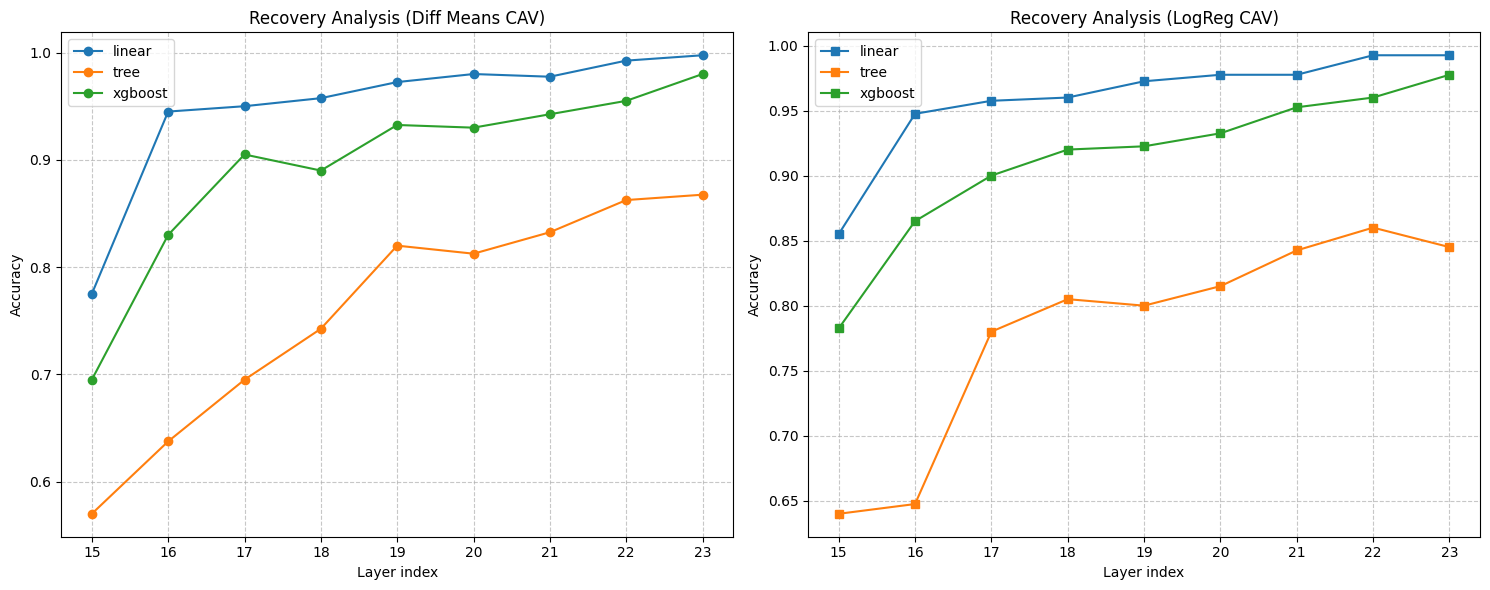

In [14]:
plot_comparison(metrics_dm, metrics_lr, "Recovery Analysis (Diff Means CAV)", "Recovery Analysis (LogReg CAV)")